In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy import special


import time

import sys
import os

from datetime import datetime
import subprocess

from os.path import exists

import read_config_utils as cu

import matplotlib as mpl

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:

feature_index = 0

fileset = 2




if fileset == 1 :
    input_dir1 = 'hist-pdf-toy-study-1d-4f-reso-0.00'
    input_dir2 = 'hist-pdf-toy-study-1d-4f-reso-0.25'
    input_dir3 = 'hist-pdf-toy-study-1d-4f-reso-0.50'
    input_dir4 = 'hist-pdf-toy-study-1d-4f-reso-0.75'
    
    plot_titles = [
        'Resolution = 0.00',
        'Resolution = 0.25',
        'Resolution = 0.50',
        'Resolution = 0.75',
    ]



if fileset == 2 :

    input_dir1 = 'bootstrap-all-in-one-inspect-of-1d-6a'
    input_dir2 = 'bootstrap-all-in-one-inspect-of-1d-7a'
    input_dir3 = 'bootstrap-all-in-one-inspect-of-1d-8a'
    input_dir4 = 'bootstrap-all-in-one-inspect-of-1d-5a'

    plot_titles = [
        'gelu, beta=1',
        'gelu, beta=4',
        'gelu, beta=16',
        'relu'
    ]

#hist_nbins = 40
hist_nbins = 120

hist_xlow = -4.0
hist_xhigh = 4.0



with open( '%s/train-and-true-samples.npy' % input_dir1, 'rb') as f :
    train_pts1 = np.load(f)
    train_det_pts1 = np.load(f)
    true_pts1 = np.load(f)
    true_det_pts1 = np.load(f)
    
print('\n\n')
print(' shape of train_pts:  %s' % str(train_pts1.shape))
print(' shape of true_pts:   %s' % str(true_pts1.shape))
print('\n\n')

with open( '%s/train-and-true-samples.npy' % input_dir2, 'rb') as f :
    train_pts2 = np.load(f)
    train_det_pts2 = np.load(f)
    true_pts2 = np.load(f)
    true_det_pts2 = np.load(f)
    
with open( '%s/train-and-true-samples.npy' % input_dir3, 'rb') as f :
    train_pts3 = np.load(f)
    train_det_pts3 = np.load(f)
    true_pts3 = np.load(f)
    true_det_pts3 = np.load(f)
    
with open( '%s/train-and-true-samples.npy' % input_dir4, 'rb') as f :
    train_pts4 = np.load(f)
    train_det_pts4 = np.load(f)
    true_pts4 = np.load(f)
    true_det_pts4 = np.load(f)




 shape of train_pts:  (100000, 1)
 shape of true_pts:   (10000, 1)





In [3]:
hist_bin_width = (hist_xhigh - hist_xlow)/hist_nbins

hist_bin_centers = np.linspace( hist_xlow + hist_bin_width/2, hist_xhigh - hist_bin_width/2, hist_nbins)

In [4]:
config_file = '%s/config.txt' % (input_dir1)

if not exists(config_file) :
    
    print("\n\n\n ******* Input file does not exist: %s\n\n\n" % config_file )
    sys.exit()
    

In [5]:
ndim = int(cu.get_par( config_file, "ndim"))
print("\n\n Number of feature dimensions: %d\n\n" % ndim)
ngen_true = int(cu.get_par( config_file, "ngen_true"))
print(' ngen_true = %d\n' % ngen_true )



 Number of feature dimensions: 1


 ngen_true = 10000



In [6]:
n_samples = 0

for fi in range(5000) :
    
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir1, fi)
    
    if exists(fname) :
        n_samples = n_samples + 1
        
print("\n\n Found %d bootstrap samples.\n\n" % n_samples )



 Found 500 bootstrap samples.




In [7]:
%%time


boot_hist_content1 = np.zeros( shape=(n_samples, hist_nbins))
boot_hist_content2 = np.zeros( shape=(n_samples, hist_nbins))
boot_hist_content3 = np.zeros( shape=(n_samples, hist_nbins))
boot_hist_content4 = np.zeros( shape=(n_samples, hist_nbins))



for bi in range(n_samples) :
    
        
  #---
        
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir1, bi)

    if not exists(fname) :  
        print('\n\n *** Missing %s' % fname )
        continue

    with open(fname,'rb') as f :            

        final_push_weights_scaled1 = np.load(f)
        print(' boot1 %3d weights: ' % bi, end='')
        print( final_push_weights_scaled1)
        
        hist_content,_ = np.histogram( train_pts1[:,feature_index], 
                                    bins=hist_nbins, 
                                    weights=final_push_weights_scaled1, range=[hist_xlow, hist_xhigh] )
        #print(hist_content)
        boot_hist_content1[bi,:] = hist_content


  #---
        
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir2, bi)

    if not exists(fname) :  
        print('\n\n *** Missing %s' % fname )
        continue

    with open(fname,'rb') as f :            

        final_push_weights_scaled2 = np.load(f)
        print(' boot2 %3d weights: ' % bi, end='')
        print( final_push_weights_scaled2)

        hist_content,_ = np.histogram( train_pts2[:,feature_index], 
                                    bins=hist_nbins, 
                                    weights=final_push_weights_scaled2, range=[hist_xlow, hist_xhigh] )
        #print(hist_content)
        boot_hist_content2[bi,:] = hist_content

  #---
        
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir3, bi)

    if not exists(fname) :  
        print('\n\n *** Missing %s' % fname )
        continue

    with open(fname,'rb') as f :            

        final_push_weights_scaled3 = np.load(f)
        print(' boot3 %3d weights: ' % bi, end='')
        print( final_push_weights_scaled3)

        hist_content,_ = np.histogram( train_pts3[:,feature_index], 
                                    bins=hist_nbins, 
                                    weights=final_push_weights_scaled3, range=[hist_xlow, hist_xhigh] )
        #print(hist_content)
        boot_hist_content3[bi,:] = hist_content

  #---
        
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir4, bi)

    if not exists(fname) :  
        print('\n\n *** Missing %s' % fname )
        continue

    with open(fname,'rb') as f :            

        final_push_weights_scaled4 = np.load(f)
        print(' boot4 %3d weights: ' % bi, end='')
        print( final_push_weights_scaled4)

        hist_content,_ = np.histogram( train_pts4[:,feature_index], 
                                    bins=hist_nbins, 
                                    weights=final_push_weights_scaled4, range=[hist_xlow, hist_xhigh] )
        #print(hist_content)
        boot_hist_content4[bi,:] = hist_content

        

 boot1   0 weights: [0.11697091 0.0906712  0.09356322 ... 0.11209176 0.11788862 0.08588561]
 boot2   0 weights: [0.11742732 0.0901913  0.09348583 ... 0.11352464 0.11785558 0.08493639]
 boot3   0 weights: [0.11524938 0.09017435 0.09357822 ... 0.11364723 0.11978078 0.08511629]
 boot4   0 weights: [0.11365804 0.09070774 0.0944335  ... 0.11224983 0.12101654 0.08501496]
 boot1   1 weights: [0.12056374 0.09169987 0.09455742 ... 0.11251987 0.11811116 0.08693207]
 boot2   1 weights: [0.12529911 0.09522667 0.09788661 ... 0.10920087 0.11246477 0.09040429]
 boot3   1 weights: [0.12240687 0.09524452 0.09819725 ... 0.10779601 0.11156824 0.09025702]
 boot4   1 weights: [0.12010162 0.09400679 0.09752734 ... 0.10634527 0.11545241 0.08842653]
 boot1   2 weights: [0.11829489 0.09081298 0.09353211 ... 0.11077047 0.11622816 0.08628266]
 boot2   2 weights: [0.11402787 0.08969705 0.09203731 ... 0.10904201 0.11621143 0.08588762]
 boot3   2 weights: [0.1130952  0.09051679 0.09305169 ... 0.11020616 0.11394511 

 boot4  34 weights: [0.11467149 0.0882872  0.09175238 ... 0.10995932 0.11519204 0.08290019]
 boot1  35 weights: [0.11760838 0.09043449 0.09308553 ... 0.10913775 0.1139775  0.08594376]
 boot2  35 weights: [0.12008187 0.09271703 0.0945411  ... 0.10540023 0.11050383 0.0893335 ]
 boot3  35 weights: [0.11728572 0.09195432 0.09415857 ... 0.10731422 0.11117711 0.08836717]
 boot4  35 weights: [0.11694297 0.09164577 0.09451266 ... 0.10768386 0.11288733 0.08696024]
 boot1  36 weights: [0.11573126 0.08926537 0.09238803 ... 0.11160794 0.11725214 0.08403828]
 boot2  36 weights: [0.11842378 0.09068911 0.09335878 ... 0.10905679 0.11442049 0.0860407 ]
 boot3  36 weights: [0.11774995 0.09159658 0.0937789  ... 0.11195885 0.11378356 0.08690087]
 boot4  36 weights: [0.11574262 0.08907473 0.09207424 ... 0.11614992 0.11604437 0.08329358]
 boot1  37 weights: [0.11491354 0.09148122 0.09407461 ... 0.10924223 0.11346083 0.08705881]
 boot2  37 weights: [0.11764072 0.09324836 0.09581838 ... 0.10864458 0.11147047 

 boot4  58 weights: [0.11864742 0.09055363 0.0939465  ... 0.1052386  0.11200452 0.0852475 ]
 boot1  59 weights: [0.11980591 0.08772081 0.09066394 ... 0.10944175 0.11535745 0.08284458]
 boot2  59 weights: [0.12064737 0.08827142 0.09184462 ... 0.11162418 0.11523079 0.08242731]
 boot3  59 weights: [0.11968265 0.08801515 0.09172044 ... 0.11146166 0.11532623 0.08226209]
 boot4  59 weights: [0.11833706 0.08836464 0.09221337 ... 0.11049186 0.11595921 0.08250614]
 boot1  60 weights: [0.12191727 0.0930062  0.09602954 ... 0.11394482 0.11914358 0.08785809]
 boot2  60 weights: [0.12163539 0.09381513 0.09635795 ... 0.11126332 0.11672226 0.08938289]
 boot3  60 weights: [0.1214393  0.09317354 0.09669671 ... 0.11019765 0.11773485 0.08746953]
 boot4  60 weights: [0.11995509 0.09253702 0.09586704 ... 0.10985575 0.11933608 0.08683211]
 boot1  61 weights: [0.10900956 0.09127452 0.09434541 ... 0.11248738 0.11723262 0.08609283]
 boot2  61 weights: [0.10999343 0.09345251 0.09624555 ... 0.11066118 0.11484319 

 boot3  95 weights: [0.11773095 0.09462658 0.0974865  ... 0.1184773  0.12081722 0.08912334]
 boot4  95 weights: [0.11626514 0.09288967 0.0963836  ... 0.11965394 0.12052289 0.08717076]
 boot1  96 weights: [0.11484209 0.08934813 0.09180613 ... 0.10682158 0.11133963 0.08520716]
 boot2  96 weights: [0.11394689 0.08913783 0.09158936 ... 0.10678875 0.11131792 0.08505587]
 boot3  96 weights: [0.11371679 0.09038248 0.09326134 ... 0.10775108 0.11302931 0.08544425]
 boot4  96 weights: [0.11202371 0.0905684  0.09342338 ... 0.10737715 0.11285884 0.08519331]
 boot1  97 weights: [0.11259772 0.09009323 0.09329083 ... 0.11294618 0.11852637 0.08475548]
 boot2  97 weights: [0.11440587 0.09073376 0.09431831 ... 0.11339441 0.11689936 0.08481218]
 boot3  97 weights: [0.11254864 0.09010174 0.09394628 ... 0.11649273 0.11500617 0.08398925]
 boot4  97 weights: [0.11049548 0.08996137 0.09407579 ... 0.1180992  0.11822339 0.08347856]
 boot1  98 weights: [0.11702049 0.08764069 0.09083881 ... 0.11171164 0.11840856 

 boot2 119 weights: [0.12004362 0.09083337 0.09350867 ... 0.11013024 0.11497368 0.08640705]
 boot3 119 weights: [0.11800625 0.09110752 0.09340455 ... 0.11287431 0.1158726  0.08677105]
 boot4 119 weights: [0.11493324 0.08941571 0.09232255 ... 0.11302471 0.11814253 0.0843397 ]
 boot1 120 weights: [0.11631329 0.0878155  0.09098319 ... 0.11017873 0.11568039 0.08249374]
 boot2 120 weights: [0.11875163 0.09001724 0.09341417 ... 0.11031514 0.11367306 0.08413045]
 boot3 120 weights: [0.116849   0.09006392 0.09361799 ... 0.10982138 0.11424569 0.08404414]
 boot4 120 weights: [0.11507844 0.08859125 0.09249195 ... 0.11320643 0.11523631 0.08240042]
 boot1 121 weights: [0.11111102 0.09136303 0.09409126 ... 0.10971717 0.11382879 0.08668846]
 boot2 121 weights: [0.11653314 0.09470095 0.09673533 ... 0.10553601 0.10872528 0.09079632]
 boot3 121 weights: [0.11377226 0.0955882  0.09823377 ... 0.10407471 0.10984298 0.0904974 ]
 boot4 121 weights: [0.11118518 0.0936338  0.0971397  ... 0.10490731 0.11278393 

...

 boot2 368 weights: [0.11565206 0.09186167 0.09515081 ... 0.11169443 0.11480536 0.08619488]
 boot3 368 weights: [0.11394462 0.09317332 0.09643349 ... 0.10863507 0.11733609 0.08733969]
 boot4 368 weights: [0.11258101 0.09227458 0.09567511 ... 0.10948395 0.1171486  0.08613207]
 boot1 369 weights: [0.11803419 0.08897185 0.09166227 ... 0.10880581 0.11435009 0.08448831]
 boot2 369 weights: [0.11789908 0.08880004 0.09091646 ... 0.10692677 0.11343047 0.08533574]
 boot3 369 weights: [0.1161796  0.08951519 0.09120629 ... 0.10869394 0.11241752 0.086139  ]
 boot4 369 weights: [0.11488476 0.08948638 0.09180158 ... 0.10883025 0.11548402 0.08559303]
 boot1 370 weights: [0.11509171 0.08924189 0.09220898 ... 0.11074902 0.11632636 0.08429632]
 boot2 370 weights: [0.11171162 0.08856239 0.09151873 ... 0.11069979 0.11677009 0.08374555]
 boot3 370 weights: [0.1107029  0.0888621  0.09237    ... 0.1077921  0.11741907 0.08345904]
 boot4 370 weights: [0.10998687 0.08839747 0.09177526 ... 0.10554202 0.11899128 

 boot2 396 weights: [0.11853872 0.09073164 0.09468309 ... 0.11273467 0.1147489  0.08409847]
 boot3 396 weights: [0.11786944 0.09054934 0.09458735 ... 0.11280298 0.1151437  0.08409598]
 boot4 396 weights: [0.11674696 0.09056786 0.09445137 ... 0.11193922 0.11760175 0.08439219]
 boot1 397 weights: [0.11338087 0.08926615 0.09235827 ... 0.11165366 0.11734959 0.0841194 ]
 boot2 397 weights: [0.11500774 0.0905826  0.0938216  ... 0.11099781 0.11519492 0.08509579]
 boot3 397 weights: [0.11205812 0.09065258 0.09445579 ... 0.11307989 0.11373208 0.08440864]
 boot4 397 weights: [0.10987355 0.08895367 0.09328412 ... 0.11558805 0.11710821 0.08247653]
 boot1 398 weights: [0.11800495 0.08851172 0.09110519 ... 0.10859178 0.11458557 0.08427827]
 boot2 398 weights: [0.11705632 0.08833051 0.09109163 ... 0.10841949 0.11365684 0.08389573]
 boot3 398 weights: [0.11458691 0.08939205 0.09159021 ... 0.10791774 0.11338752 0.08529253]
 boot4 398 weights: [0.11383704 0.08855769 0.09141841 ... 0.10869136 0.11427931 

 boot1 424 weights: [0.12065257 0.08607248 0.08886108 ... 0.1068582  0.112776   0.08145178]
 boot2 424 weights: [0.11827005 0.08667709 0.08953255 ... 0.10654605 0.11202665 0.08190457]
 boot3 424 weights: [0.11774991 0.08668127 0.08969801 ... 0.10408244 0.11170655 0.08189392]
 boot4 424 weights: [0.11767094 0.08593276 0.08933315 ... 0.10150607 0.11247455 0.08116075]
 boot1 425 weights: [0.11830096 0.08329406 0.08608057 ... 0.10522474 0.11199334 0.07877203]
 boot2 425 weights: [0.11812941 0.08368974 0.08612361 ... 0.10327804 0.110262   0.07971369]
 boot3 425 weights: [0.1163076  0.08480115 0.08659671 ... 0.1027442  0.10820878 0.08138661]
 boot4 425 weights: [0.11569805 0.08502247 0.08713412 ... 0.10349986 0.11047767 0.08094405]
 boot1 426 weights: [0.11150099 0.08862926 0.09163696 ... 0.11089473 0.11681329 0.08365722]
 boot2 426 weights: [0.10758574 0.08597965 0.08841713 ... 0.10991165 0.11861582 0.08225767]
 boot3 426 weights: [0.1070056  0.08741212 0.09012572 ... 0.10758625 0.12181055 

 boot1 452 weights: [0.1228388  0.09011713 0.09276792 ... 0.10987779 0.11558222 0.085713  ]
 boot2 452 weights: [0.12606667 0.09303693 0.09556983 ... 0.10845062 0.11225821 0.08856969]
 boot3 452 weights: [0.12239965 0.09475536 0.09705648 ... 0.10700514 0.11232556 0.09008345]
 boot4 452 weights: [0.12064479 0.09409971 0.096674   ... 0.10627946 0.11362124 0.08879437]
 boot1 453 weights: [0.11817922 0.09096156 0.09403277 ... 0.1140731  0.12046307 0.08591221]
 boot2 453 weights: [0.1247424  0.09503632 0.09831509 ... 0.1119129  0.11449775 0.08922871]
 boot3 453 weights: [0.12080482 0.09584103 0.09970163 ... 0.11395256 0.11683487 0.08912213]
 boot4 453 weights: [0.11722327 0.09408411 0.09807059 ... 0.11468439 0.11980205 0.08777985]
 boot1 454 weights: [0.1144433  0.08746735 0.09032075 ... 0.10908215 0.11517482 0.08278364]
 boot2 454 weights: [0.11818478 0.0910414  0.0938709  ... 0.10702478 0.11095094 0.08593629]
 boot3 454 weights: [0.11550122 0.09242466 0.09483418 ... 0.10733085 0.11047979 

 boot1 480 weights: [0.119439   0.09190552 0.09496046 ... 0.11403641 0.11980133 0.08680958]
 boot2 480 weights: [0.11900759 0.09181415 0.09481014 ... 0.11310018 0.11884126 0.08682281]
 boot3 480 weights: [0.1176643  0.09268457 0.09596143 ... 0.11517179 0.11966471 0.08714887]
 boot4 480 weights: [0.11609142 0.09254966 0.09555681 ... 0.11724661 0.12251023 0.0863363 ]
 boot1 481 weights: [0.11807569 0.08895088 0.09195339 ... 0.1109178  0.11683005 0.08395148]
 boot2 481 weights: [0.12127489 0.08976219 0.09236563 ... 0.10929566 0.11475239 0.08543223]
 boot3 481 weights: [0.11894578 0.09015795 0.09284676 ... 0.11273242 0.11488983 0.08534368]
 boot4 481 weights: [0.11580229 0.08961555 0.09289084 ... 0.11422487 0.11753797 0.08414779]
 boot1 482 weights: [0.11562568 0.08690394 0.09013895 ... 0.11099541 0.11741258 0.08158563]
 boot2 482 weights: [0.11874265 0.09186962 0.09502695 ... 0.10777372 0.11161128 0.08604155]
 boot3 482 weights: [0.11547074 0.09255317 0.09561509 ... 0.10930291 0.11212915 

In [8]:
print('\n\n Done reading in weights\n\n')



 Done reading in weights




<function matplotlib.pyplot.show(close=None, block=None)>

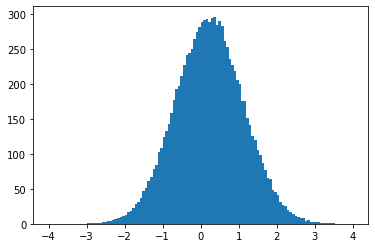

In [9]:
plt.hist( train_pts1[:,feature_index], bins=hist_nbins, weights=final_push_weights_scaled1, range=[hist_xlow, hist_xhigh] )
plt.show

In [10]:
hist_corr_mat1 = np.zeros( shape=(hist_nbins, hist_nbins) )
hist_cov_mat1 = np.zeros( shape=(hist_nbins, hist_nbins) )

hist_corr_mat2 = np.zeros( shape=(hist_nbins, hist_nbins) )
hist_cov_mat2 = np.zeros( shape=(hist_nbins, hist_nbins) )

hist_corr_mat3 = np.zeros( shape=(hist_nbins, hist_nbins) )
hist_cov_mat3 = np.zeros( shape=(hist_nbins, hist_nbins) )

hist_corr_mat4 = np.zeros( shape=(hist_nbins, hist_nbins) )
hist_cov_mat4 = np.zeros( shape=(hist_nbins, hist_nbins) )


for bi in range(hist_nbins) :
    
    for bj in range( hist_nbins ) :
        
       #---
        
        ccm = np.corrcoef( np.row_stack( ((boot_hist_content1[:,bi], boot_hist_content1[:,bj])) ) )
        cvm =      np.cov( np.row_stack( ((boot_hist_content1[:,bi], boot_hist_content1[:,bj])) ) )
        
        hist_corr_mat1[bi,bj] = ccm[0,1]
        
        hist_cov_mat1[bi,bj] = cvm[0,1]
        
       #---
        
        ccm = np.corrcoef( np.row_stack( ((boot_hist_content2[:,bi], boot_hist_content2[:,bj])) ) )
        cvm =      np.cov( np.row_stack( ((boot_hist_content2[:,bi], boot_hist_content2[:,bj])) ) )
        
        hist_corr_mat2[bi,bj] = ccm[0,1]
        
        hist_cov_mat2[bi,bj] = cvm[0,1]

       #---
        
        ccm = np.corrcoef( np.row_stack( ((boot_hist_content3[:,bi], boot_hist_content3[:,bj])) ) )
        cvm =      np.cov( np.row_stack( ((boot_hist_content3[:,bi], boot_hist_content3[:,bj])) ) )
        
        hist_corr_mat3[bi,bj] = ccm[0,1]
        
        hist_cov_mat3[bi,bj] = cvm[0,1]
        
       #---
        
        ccm = np.corrcoef( np.row_stack( ((boot_hist_content4[:,bi], boot_hist_content4[:,bj])) ) )
        cvm =      np.cov( np.row_stack( ((boot_hist_content4[:,bi], boot_hist_content4[:,bj])) ) )
        
        hist_corr_mat4[bi,bj] = ccm[0,1]
        
        hist_cov_mat4[bi,bj] = cvm[0,1]

/home/owen/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/owen/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<function matplotlib.pyplot.show(close=None, block=None)>

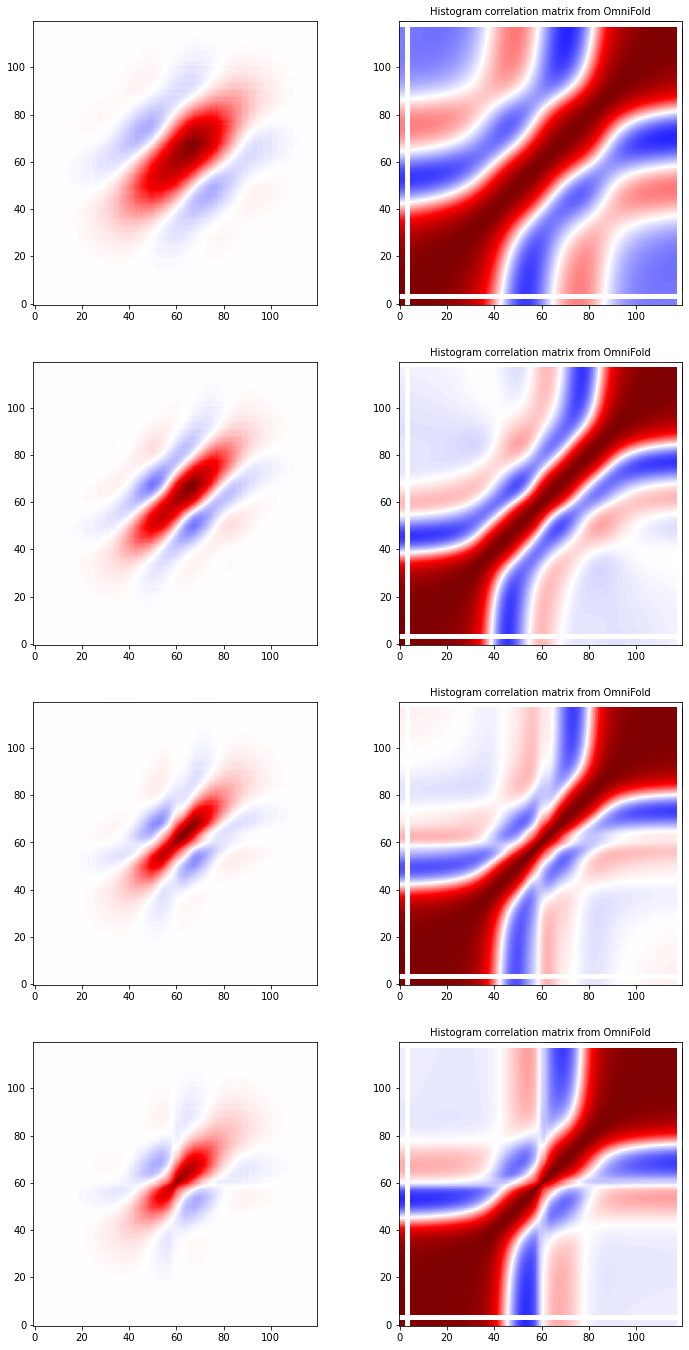

In [11]:
fs = 6

fig,ax = plt.subplots( 4, 2, figsize=(2*fs,4*fs))


#--

axi = ax[0,0]
max_cov_element1 = np.max(hist_cov_mat1)
im_covmat1 = axi.imshow(hist_cov_mat1, origin='lower',
                       vmin=-1*max_cov_element1, vmax=max_cov_element1,
                       cmap='seismic')
#axi.figure.colorbar( im_covmat1, ax=ax[0] )

axi = ax[0,1]
im1 = axi.imshow(hist_corr_mat1, cmap='seismic', origin='lower', vmin=-1, vmax=1)
#axi.figure.colorbar( im1, ax=ax[1] )
axi.set_title('Histogram correlation matrix from OmniFold', fontsize=10)


#--

axi = ax[1,0]
max_cov_element2 = np.max(hist_cov_mat2)
im_covmat1 = axi.imshow(hist_cov_mat2, origin='lower',
                       vmin=-1*max_cov_element2, vmax=max_cov_element2,
                       cmap='seismic')
#axi.figure.colorbar( im_covmat1, ax=ax[0] )

axi = ax[1,1]
im2 = axi.imshow(hist_corr_mat2, cmap='seismic', origin='lower', vmin=-1, vmax=1)
#axi.figure.colorbar( im1, ax=ax[1] )
axi.set_title('Histogram correlation matrix from OmniFold', fontsize=10)


#--

axi = ax[2,0]
max_cov_element3 = np.max(hist_cov_mat3)
im_covmat1 = axi.imshow(hist_cov_mat3, origin='lower',
                       vmin=-1*max_cov_element3, vmax=max_cov_element3,
                       cmap='seismic')
#axi.figure.colorbar( im_covmat1, ax=ax[0] )

axi = ax[2,1]
im3 = axi.imshow(hist_corr_mat3, cmap='seismic', origin='lower', vmin=-1, vmax=1)
#axi.figure.colorbar( im1, ax=ax[1] )
axi.set_title('Histogram correlation matrix from OmniFold', fontsize=10)

#--

axi = ax[3,0]
max_cov_element4 = np.max(hist_cov_mat4)
im_covmat1 = axi.imshow(hist_cov_mat4, origin='lower',
                       vmin=-1*max_cov_element4, vmax=max_cov_element4,
                       cmap='seismic')
#axi.figure.colorbar( im_covmat1, ax=ax[0] )

axi = ax[3,1]
im4 = axi.imshow(hist_corr_mat4, cmap='seismic', origin='lower', vmin=-1, vmax=1)
#axi.figure.colorbar( im1, ax=ax[1] )
axi.set_title('Histogram correlation matrix from OmniFold', fontsize=10)


plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

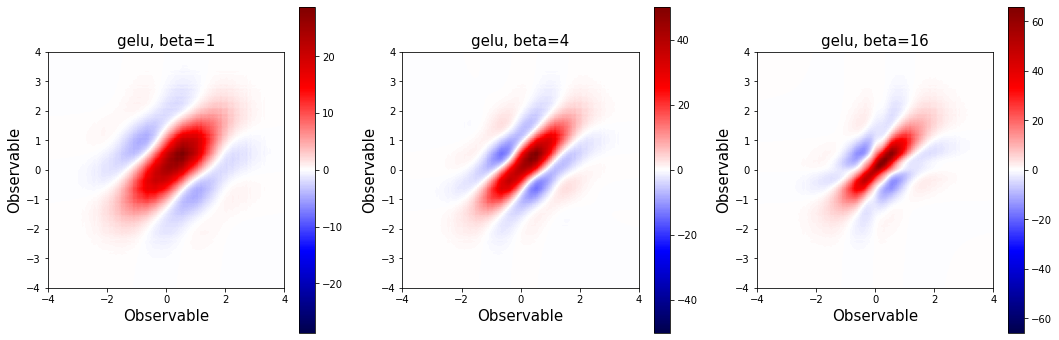

In [12]:
fs = 6

fonts = 15

fig,ax = plt.subplots( 1, 3, figsize=(3*fs,fs))


#---

axi = ax[0]
max_cov_element = np.max(hist_cov_mat1)
im_covmat1 = axi.imshow(hist_cov_mat1, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat1, ax=axi )

axi.set_title( plot_titles[0], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )


#---

axi = ax[1]
max_cov_element = np.max(hist_cov_mat2)
im_covmat2 = axi.imshow(hist_cov_mat2, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat2, ax=axi )

axi.set_title(plot_titles[1], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )

#---

axi = ax[2]
max_cov_element = np.max(hist_cov_mat3)
im_covmat3 = axi.imshow(hist_cov_mat3, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat3, ax=axi )

axi.set_title(plot_titles[2], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )


#plt.savefig( 'paper-plots/weight-histogram-covariance-1d.pdf', bbox_inches='tight' )



plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

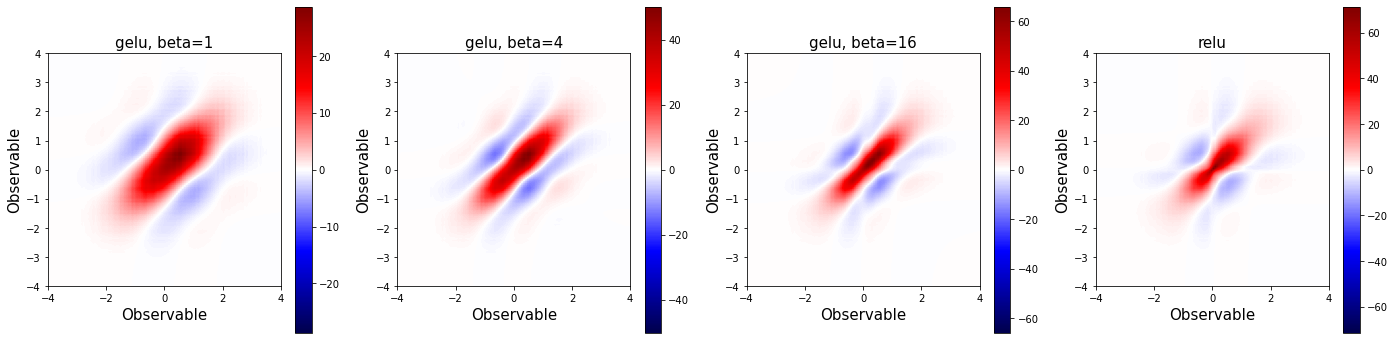

In [13]:
fs = 6

fonts = 15

fig,ax = plt.subplots( 1, 4, figsize=(4*fs,fs))


#---

axi = ax[0]
max_cov_element = np.max(hist_cov_mat1)
im_covmat1 = axi.imshow(hist_cov_mat1, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat1, ax=axi )

axi.set_title(plot_titles[0], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )


#---

axi = ax[1]
max_cov_element = np.max(hist_cov_mat2)
im_covmat2 = axi.imshow(hist_cov_mat2, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat2, ax=axi )

axi.set_title(plot_titles[1], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )

#---

axi = ax[2]
max_cov_element = np.max(hist_cov_mat3)
im_covmat3 = axi.imshow(hist_cov_mat3, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat3, ax=axi )

axi.set_title(plot_titles[2], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )

#---

axi = ax[3]
max_cov_element = np.max(hist_cov_mat4)
im_covmat4 = axi.imshow(hist_cov_mat4, cmap='seismic', origin='lower', 
                         extent=[hist_xlow,hist_xhigh,hist_xlow,hist_xhigh],
                        vmin=-1*max_cov_element, vmax=max_cov_element
                        )
axi.figure.colorbar( im_covmat4, ax=axi )

axi.set_title(plot_titles[3], fontsize=fonts )
axi.set_xlabel( 'Observable', fontsize=fonts )
axi.set_ylabel( 'Observable', fontsize=fonts )


plt.savefig( 'plots/weight-histogram-covariance-1d-set%d.pdf' % fileset, bbox_inches='tight' )



plt.show